<a href="https://colab.research.google.com/github/aesquivel94/operational-error-analyzer/blob/main/warehouse_operational_error_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Operational Error Analyzer**

Warehouse errors are rarely isolated. A scan failure, labeling issue, or wrong item can ripple through the workflow, creating delays, rework, and hidden operational costs. Over time, these issues impact customer satisfaction by increasing wait times, reducing service quality, and leading to incorrect orders.

This project analyzes warehouse operational errors to identify the most frequent issues, quantify their impact on operational time loss, and uncover how failures propagate across process steps.

I built this project to demonstrate how Python and data analysis can be used to identify systemic process weaknesses and turn operational friction into actionable insights that support better decision-making.

## Executive Summary

This project analyzes warehouse operational errors to uncover patterns, root causes, and opportunities for process improvement.

### Key Findings

• Scan failures act as a primary upstream driver of downstream errors.  
• Certain workflow steps concentrate a disproportionate number of issues.  
• Error chains indicate systemic process weaknesses rather than isolated failures.  

### Business Impact

The results highlight how data-driven analysis can identify critical failure points, reduce operational time loss, and improve overall process efficiency and reliability.

## Business Problem

This project analyzes warehouse operational errors to uncover patterns, root causes, and opportunities for process improvement.

### Key Findings

• Scan failures act as a primary upstream driver of downstream errors  
• Certain workflow steps concentrate a disproportionate number of issues  
• Error chains indicate systemic process weaknesses rather than isolated failures  

### Business Impact

The results highlight how data-driven analysis can identify critical failure points, reduce operational time loss, and improve overall process efficiency and reliability.

## Project Objectives

This project aims to move beyond basic error tracking and uncover how operational failures impact performance across the workflow. The analysis focuses on:

1. Identifying the most frequent operational errors  
2. Measuring which errors generate the highest operational time loss  
3. Detecting where errors occur across different workflow stages  
4. Analyzing recurring error chains and their dependencies  
5. Exploring whether errors can be predicted using available data  
6. Recommending targeted actions to improve operational efficiency  

## Dataset and Simulation Design

This project uses a synthetic dataset designed to reflect realistic warehouse operations. The data was generated to simulate common workflow stages, error types, and their potential impact on performance.

### Key Features of the Simulation

• Process-specific error probabilities to reflect differences across workflow stages.  
• Root-cause relationships between errors to simulate downstream effects.  
• Identifier types such as SKU, barcode, and LPN.  
• Estimated time impact associated with each error type.  
• Simulated error chains to model how failures propagate through the system.  

### Assumptions

The dataset is not based on real production data but is designed to approximate realistic operational behavior. The goal is to demonstrate how data analysis can be applied to identify patterns, quantify impact, and support decision-making in a warehouse environment.

## Import Packages and Setup

This section loads the required libraries and defines the default visualization style used throughout the analysis.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as mtick

# Set visualization style for consistency across charts
sns.set_theme(style="whitegrid")

## Generate Synthetic Warehouse Error Data

This section simulates warehouse operational events, including error types, root causes, and their estimated impact on processing time.

In [7]:
# Reproducible random seed
rng = np.random.default_rng(42)

# Number of simulated events
n = 400

# -----------------------------
# Operational dimensions
# -----------------------------
shifts = ["A", "B", "C"]
process_steps = ["receiving", "picking", "packing", "back_to_stock"]

# -----------------------------
# Error probabilities by process step
# -----------------------------
step_error_weights = {
    "receiving": {
        "scan_failure": 0.35,
        "damage": 0.30,
        "lpn_error": 0.25,
        "missing_item": 0.10,
    },
    "picking": {
        "wrong_item": 0.35,
        "missing_item": 0.30,
        "lpn_error": 0.20,
        "scan_failure": 0.15,
    },
    "packing": {
        "wrong_item": 0.30,
        "damage": 0.25,
        "scan_failure": 0.25,
        "missing_item": 0.20,
    },
    "back_to_stock": {
        "missing_item": 0.35,
        "lpn_error": 0.30,
        "scan_failure": 0.20,
        "wrong_item": 0.15,
    },
}

# -----------------------------
# Error mappings
# -----------------------------
error_to_root = {
    "wrong_item": ["incorrect_location", "training_gap", "mislabel"],
    "missing_item": ["inventory_mismatch", "incorrect_location", "system_lag"],
    "scan_failure": ["damaged_label", "system_lag", "mislabel"],
    "lpn_error": ["mislabel", "system_lag", "training_gap"],
    "damage": ["training_gap", "incorrect_location", "damaged_label"],
}

error_to_identifier = {
    "wrong_item": ["sku", "barcode"],
    "missing_item": ["sku", "lpn"],
    "scan_failure": ["barcode", "lpn"],
    "lpn_error": ["lpn"],
    "damage": ["barcode", "sku"],
}

# -----------------------------
# Helper function
# -----------------------------
def weighted_choice(options_dict):
    """Sample a key based on defined probabilities."""
    options = list(options_dict.keys())
    probs = list(options_dict.values())
    return rng.choice(options, p=probs)

# -----------------------------
# Generate dates
# -----------------------------
start = np.datetime64("2025-01-01")
dates = start + rng.integers(0, 90, size=n).astype("timedelta64[D]")

rows = []

# -----------------------------
# Simulate operational events
# -----------------------------
for i in range(n):

    # Operational context
    shift = rng.choice(shifts, p=[0.36, 0.34, 0.30])
    step = rng.choice(process_steps, p=[0.20, 0.35, 0.25, 0.20])

    # Error characteristics
    error_type = weighted_choice(step_error_weights[step])
    root_cause = rng.choice(error_to_root[error_type])
    identifier_type = rng.choice(error_to_identifier[error_type])

    # Estimated operational impact
    base = rng.gamma(shape=2.0, scale=7.0)

    multiplier = {
        "missing_item": 1.4,
        "wrong_item": 1.3,
        "lpn_error": 1.2,
        "scan_failure": 1.0,
        "damage": 1.1,
    }[error_type]

    impact_minutes = int(round(base * multiplier))

    rows.append([
        str(dates[i]),
        shift,
        step,
        error_type,
        root_cause,
        identifier_type,
        impact_minutes
    ])

# -----------------------------
# Final dataset
# -----------------------------
df = pd.DataFrame(rows, columns=[
    "date",
    "shift",
    "process_step",
    "error_type",
    "root_cause",
    "identifier_type",
    "impact_minutes"
])

df.head()

,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19


## Data Validation and Quality Check

This section verifies the structure, data types, and consistency of the dataset, ensuring that all variables are correctly generated and suitable for analysis.

In [8]:
print("🔹 Preview of dataset")
display(df.head())

print("\n🔹 Dataset structure")
df.info()

print("\n🔹 Summary statistics")
display(df.describe())

print("\n🔹 Missing values")
display(df.isnull().sum())

print("\n🔹 Frequency error type")
df["error_type"].value_counts()

🔹 Preview of dataset


,date,shift,process_step,error_type,root_cause,identifier_type,impact_minutes
0,2025-01-09,C,back_to_stock,lpn_error,system_lag,lpn,18
1,2025-03-11,A,packing,wrong_item,incorrect_location,sku,7
2,2025-02-28,A,back_to_stock,scan_failure,system_lag,barcode,12
3,2025-02-09,C,picking,wrong_item,mislabel,sku,22
4,2025-02-08,A,back_to_stock,missing_item,incorrect_location,lpn,19



🔹 Dataset structure
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   date             400 non-null    object
 1   shift            400 non-null    object
 2   process_step     400 non-null    object
 3   error_type       400 non-null    object
 4   root_cause       400 non-null    object
 5   identifier_type  400 non-null    object
 6   impact_minutes   400 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 22.0+ KB

🔹 Summary statistics


,impact_minutes
count,400.000000
mean,17.162500
std,12.176278
min,1.000000
25%,8.750000
50%,15.000000
75%,23.000000
max,75.000000



🔹 Missing values


,0
date,0
shift,0
process_step,0
error_type,0
root_cause,0
identifier_type,0
impact_minutes,0



🔹 Frequency error type


,count
error_type,
missing_item,96
wrong_item,94
scan_failure,91
lpn_error,70
damage,49


### Validation Notes

The dataset is well-structured and suitable for analysis:

• All core operational variables are complete, with no missing values  
• Error types are relatively balanced across categories, supporting meaningful comparisons  
• Missing values were identified in `error_cost` and `risk_score`, caused by events without a prior error  

To ensure consistency, missing values in these fields were replaced with 0, representing cases where no additional cost or risk was generated.

This preprocessing step ensures that the dataset is complete and reliable for further analysis and modeling.

In [9]:
#df["error_cost"] = df["error_cost"].fillna(0)
#df["risk_score"] = df["risk_score"].fillna(0)

## Error Frequency Analysis

### Question
**Which operational errors occur most frequently?**

This section identifies the most common error types, providing an initial view of where operational issues are concentrated.

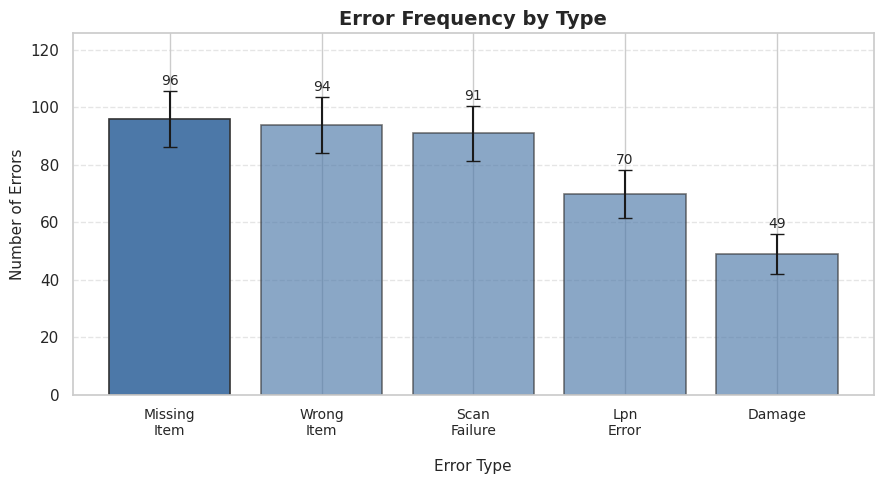

In [10]:
error_counts = df["error_type"].value_counts()

# Format category labels for readability
def format_label(text):
    words = text.replace("_", " ").title().split()

    if len(words) == 2:
        return f"{words[0]}\n{words[1]}"

    return "\n".join(words)

labels = [format_label(x) for x in error_counts.index]

# Approximate variability for visual context
error = np.sqrt(error_counts.values)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    labels,
    error_counts.values,
    yerr=error,
    capsize=5,
    color="#4C78A8",   # colorblind-friendly palette
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Add value labels above bars
for i, v in enumerate(error_counts.values):
    plt.text(
        i,
        v + error[i] + 2,
        str(v),
        ha="center",
        fontsize=10
    )

# Highlight the most frequent error
max_idx = error_counts.values.argmax()

for i, bar in enumerate(bars):
    if i == max_idx:
        bar.set_alpha(1.0)
    else:
        bar.set_alpha(0.65)

# Format y-axis labels for readability
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.title("Error Frequency by Type", fontsize=14, weight="bold")
plt.ylabel("Number of Errors", fontsize=11)
plt.xlabel("Error Type", fontsize=11, labelpad=15)
plt.xticks(fontsize=10)

# Improve readability with horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.ylim(0, max(error_counts.values + error) + 20)
plt.tight_layout()
plt.show()

### Key Insight

The top three errors — **Missing Item**, **Wrong Item**, and **Scan Failure** — occur at very similar frequencies, indicating that no single error type overwhelmingly dominates the process.

This suggests that operational inefficiencies are distributed across multiple failure points rather than concentrated in one area.

In [11]:
# -----------------------------
# Operational summary metrics
# -----------------------------
total_errors = len(df)
total_minutes = df["impact_minutes"].sum()

# Most frequent error type
top_error = (
    df["error_type"]
    .value_counts()
    .idxmax()
    .replace("_", " ")
    .title()
)

# Error type with highest total time impact
top_impact = (
    df.groupby("error_type")["impact_minutes"]
    .sum()
    .idxmax()
    .replace("_", " ")
    .title()
)

# -----------------------------
# Display summary
# -----------------------------
print("🔹 Operational Summary\n")

print(f"📊 Total Errors: {total_errors}")
print(f"⏱️ Total Minutes Lost: {total_minutes:,}")
print(f"🔁 Most Frequent Error: {top_error}")
print(f"💥 Highest-Impact Error: {top_impact}")

🔹 Operational Summary

📊 Total Errors: 400
⏱️ Total Minutes Lost: 6,865
🔁 Most Frequent Error: Missing Item
💥 Highest-Impact Error: Missing Item


The same error type (**Missing Item**) is both the most frequent and the highest-impact, making it the most critical area for operational improvement.

Focusing on this issue represents the highest-leverage opportunity to reduce both error volume and overall operational time loss.

## Errors by Process Step

### Question
**Where do operational errors occur within the workflow?**

This section examines how error types are distributed across process steps to identify where failures concentrate and where intervention is most needed.

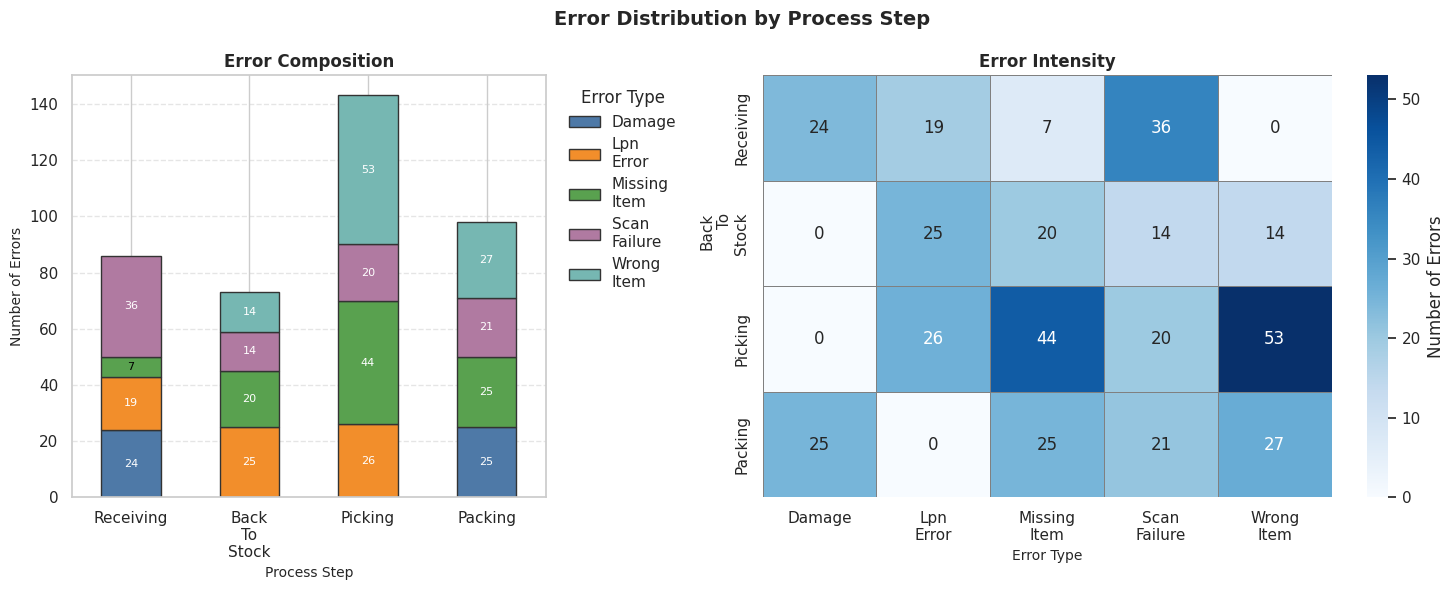

In [12]:
# -----------------------------
# Error distribution by process step (split layout)
# -----------------------------
step_errors = pd.crosstab(df["process_step"], df["error_type"])

process_order = ["receiving", "back_to_stock", "picking", "packing"]
step_errors = step_errors.loc[process_order]

# Format labels
def format_label(text):
    words = text.replace("_", " ").title().split()
    return "\n".join(words)

step_errors.index = [format_label(x) for x in step_errors.index]
step_errors.columns = [format_label(x) for x in step_errors.columns]

# Colorblind-friendly palette
colors = ["#4E79A7", "#F28E2B", "#59A14F", "#B07AA1", "#76B7B2"]

# Create split layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.5]})

# -----------------------------
# Left: Stacked Bar Chart
# -----------------------------
ax = axes[0]

step_errors.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=colors,
    edgecolor="#333333",
    linewidth=1
)

ax.set_title("Error Composition", fontsize=12, weight="bold")
ax.set_xlabel("Process Step", fontsize=10)
ax.set_ylabel("Number of Errors", fontsize=10)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Move legend OUTSIDE
ax.legend(
    title="Error Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

# -----------------------------
# Add labels inside stacked bars
# -----------------------------
for container in ax.containers:
    for bar in container:
        height = bar.get_height()

        if height > 0:  # avoid labeling empty segments
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + height / 2,
                int(height),
                ha="center",
                va="center",
                fontsize=8,
                color="white" if height > 10 else "black"
            )

# -----------------------------
# Right: Heatmap
# -----------------------------
sns.heatmap(
    step_errors,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Number of Errors"},
    ax=axes[1]
)

axes[1].set_title("Error Intensity", fontsize=12, weight="bold")
axes[1].set_xlabel("Error Type", fontsize=10)
axes[1].set_ylabel("")

# Global title
plt.suptitle("Error Distribution by Process Step", fontsize=14, weight="bold")

plt.tight_layout()
plt.show()

### Key Insight

Errors are not evenly distributed across the workflow. The **picking** stage stands out as the most error-prone step, with a high concentration of **wrong_item** and **missing_item** issues.

In contrast, earlier stages such as **receiving** show a different pattern, with more **scan_failure** and **damage** errors, indicating that each process step faces distinct operational challenges.

### Focus Area

The **picking** process generates the highest number of **wrong_item** errors, making it the most critical intervention point.

Because picking directly determines order accuracy, failures at this stage are more likely to propagate downstream and impact customer satisfaction.

## Operational Time Lost by Error Type

### Question
**Which operational errors generate the greatest time loss?**

Not all errors are equal. Some occur frequently, while others consume significantly more time and resources.

This analysis measures the **total time lost per error type** to identify which failures drive the highest operational cost.

In operational environments, the most common problem is not always the most expensive one.

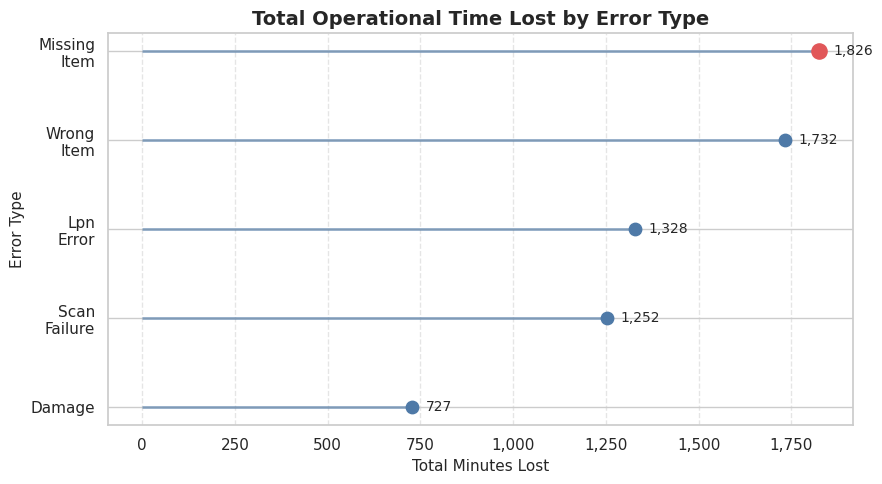

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# -----------------------------
# Total operational time lost by error type
# -----------------------------
cost_analysis = (
    df.groupby("error_type")["impact_minutes"]
    .sum()
    .sort_values(ascending=True)
)

# Format category labels for readability
def format_label(text):
    return "\n".join(text.replace("_", " ").title().split())

labels = [format_label(x) for x in cost_analysis.index]
values = cost_analysis.values

plt.figure(figsize=(9, 5))

# Draw reference lines for comparison
plt.hlines(
    y=labels,
    xmin=0,
    xmax=values,
    color="#4E79A7",
    alpha=0.6,
    linewidth=2
)

# Plot points for each error type
plt.scatter(
    values,
    labels,
    color="#4E79A7",
    s=80
)

# Emphasize the highest-impact error
max_idx = values.argmax()
plt.scatter(
    values[max_idx],
    labels[max_idx],
    color="#E15759",
    s=120,
    zorder=3
)

# Display values for quick comparison
offset = max(values) * 0.02
for i, v in enumerate(values):
    plt.text(
        v + offset,
        labels[i],
        f"{v:,}",
        va="center",
        fontsize=10
    )

plt.title("Total Operational Time Lost by Error Type", fontsize=14, weight="bold")
plt.xlabel("Total Minutes Lost", fontsize=11)
plt.ylabel("Error Type", fontsize=11)

# Improve readability with vertical reference lines
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Format x-axis labels with commas
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

### Key Insight

Operational time loss is highly concentrated. A single error type drives a disproportionate share of total impact.

**Missing Item** is the dominant cost driver, combining high frequency with significant recovery time. This makes it the most critical target for process improvement.

Addressing this issue would yield the largest reduction in overall operational inefficiency.

### Focus Area

Prioritize improvements in processes related to **Missing Item** errors, particularly in stages where inventory accuracy and item tracking are critical.

Reducing this error type has the highest potential to decrease both operational delays and total time lost.



> A single error type represents the highest-leverage opportunity for improving operational efficiency.

This alignment between frequency and impact reinforces the urgency of addressing this issue.


## Simulating Error Propagation

What goes here:

previous_error logic
explanation that chains are simulated to model downstream failure patterns

Why this matters:
Separate this from the analysis.
Right now it is mixed into the middle.
It should become its own clear setup step.

## Recurring Error Chain Analysis
Question answered:
Which operational errors tend to trigger other errors?

Operational failures rarely occur in isolation.
One process breakdown can propagate downstream and generate additional errors.

This analysis identifies recurring error chains, helping reveal systemic weaknesses in the workflow.

Understanding these patterns allows operations teams to target root causes instead of isolated symptoms.

In [17]:
df['previous_error'] = df['error_type'].shift(1)

top_chains = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
    .head(5)
)

top_chains

,previous_error,error_type,count
23,wrong_item,scan_failure,28
17,scan_failure,missing_item,25
11,missing_item,lpn_error,24
14,missing_item,wrong_item,24
19,scan_failure,wrong_item,23


In [ ]:
chain_counts = (
    df.groupby(["previous_error", "error_type"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

sankey_data = chain_counts.head(12).copy()
chain_counts.head(10)

## Error Transition Matrix

**Question**  
How likely is one error to be followed by another?

Operational errors are not independent events. A failure in one step can increase the probability of subsequent errors.

This analysis models the likelihood of transitioning from one error type to another, revealing how issues propagate through the workflow.

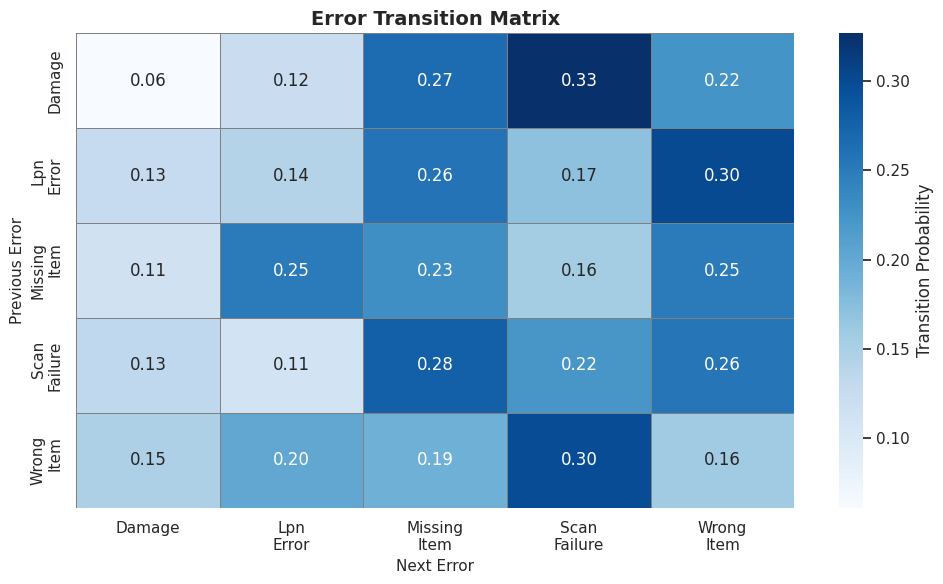

In [20]:
# -----------------------------
# Error transition probability matrix
# -----------------------------

# Create transition counts
transition_counts = pd.crosstab(
    df["previous_error"],
    df["error_type"]
)

# Convert counts to probabilities (row-wise)
transition_probs = transition_counts.div(
    transition_counts.sum(axis=1),
    axis=0
)

# Format labels for readability
def format_label(text):
    return "\n".join(text.replace("_", " ").title().split())

transition_probs.index = [format_label(x) for x in transition_probs.index]
transition_probs.columns = [format_label(x) for x in transition_probs.columns]

plt.figure(figsize=(10, 6))

# Heatmap visualization
sns.heatmap(
    transition_probs,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Transition Probability"}
)

plt.title("Error Transition Matrix", fontsize=14, weight="bold")
plt.xlabel("Next Error", fontsize=11)
plt.ylabel("Previous Error", fontsize=11)

plt.tight_layout()
plt.show()

In [22]:
# Identify strongest transitions
transition_probs.stack().sort_values(ascending=False).head(5)

,,0
Damage,Scan\nFailure,0.326531
Lpn\nError,Wrong\nItem,0.300000
Wrong\nItem,Scan\nFailure,0.297872
Scan\nFailure,Missing\nItem,0.277778
Damage,Missing\nItem,0.265306


### Key Insight

Error transitions are not random. Certain error types show a higher likelihood of leading to specific downstream failures.

This indicates that operational issues can propagate through the workflow, creating chains of related errors rather than isolated incidents.

In particular, errors related to item identification and scanning appear more likely to trigger subsequent issues, reinforcing their role as critical failure points.

## Visualizing Error Propagation with a Sankey Diagram

Operational errors often occur as part of a sequence rather than as isolated events.

This visualization maps how errors flow from one stage to another, highlighting the most common transitions and revealing how failures propagate through the workflow.

In [26]:
import pandas as pd
import plotly.graph_objects as go

# -----------------------------
# Prepare transition data
# -----------------------------
sankey_data = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
)

# Remove events without a prior error
sankey_data = sankey_data[sankey_data["previous_error"] != "no_previous"].copy()

# Keep only the strongest transitions to reduce clutter
sankey_data = sankey_data.sort_values("count", ascending=False).head(10)

# Format labels for readability
def format_label(text):
    return text.replace("_", " ").title()

# Create separate node groups for source and target
left_nodes = [f"Previous: {format_label(x)}" for x in sankey_data["previous_error"].unique()]
right_nodes = [f"Next: {format_label(x)}" for x in sankey_data["error_type"].unique()]
all_nodes = left_nodes + right_nodes

# Map node labels to indices
node_index = {label: i for i, label in enumerate(all_nodes)}

# Build source and target indices
sources = sankey_data["previous_error"].map(
    lambda x: node_index[f"Previous: {format_label(x)}"]
)
targets = sankey_data["error_type"].map(
    lambda x: node_index[f"Next: {format_label(x)}"]
)
values = sankey_data["count"]

# Color mapping for error types
color_map = {
    "Damage": "#4E79A7",
    "Lpn Error": "#F28E2B",
    "Missing Item": "#59A14F",
    "Scan Failure": "#B07AA1",
    "Wrong Item": "#E15759",
}

# Assign node colors
node_colors = []
for node in all_nodes:
    error_name = node.split(": ", 1)[1]
    node_colors.append(color_map.get(error_name, "#76B7B2"))

# Convert hex colors to RGBA for softer links
def hex_to_rgba(hex_color, alpha=0.35):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

# Color links based on their source error
link_colors = [
    hex_to_rgba(color_map.get(format_label(prev), "#76B7B2"), alpha=0.35)
    for prev in sankey_data["previous_error"]
]

# Position nodes explicitly for a clearer left-to-right layout
left_x = [0.08] * len(left_nodes)
right_x = [0.88] * len(right_nodes)

left_y = list(pd.Series(range(len(left_nodes))).rank(pct=True))
right_y = list(pd.Series(range(len(right_nodes))).rank(pct=True))

# -----------------------------
# Build Sankey diagram
# -----------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=25,
                thickness=22,
                line=dict(color="rgba(50,50,50,0.5)", width=0.8),
                label=all_nodes,
                color=node_colors,
                x=left_x + right_x,
                y=left_y + right_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )
    ]
)

fig.update_layout(
    title_text="Error Propagation Flow",
    font=dict(size=12),
    width=1100,
    height=650,
    margin=dict(l=20, r=20, t=50, b=20)
)

fig.show()

### Key Insight

Error propagation is not random. A small number of transitions account for the clearest downstream failure patterns.

By separating previous and next errors, the Sankey diagram highlights which upstream issues are most likely to trigger additional operational problems. This makes it easier to identify where intervention can break recurring error chains.

The strongest flows point to a limited set of high-priority transitions, reinforcing the value of targeting root causes rather than isolated symptoms.

### Why This Matters

This view shifts the analysis from counting individual errors to understanding how failures spread through the workflow.

By identifying the strongest upstream-to-downstream transitions, operations teams can focus on breaking the chains that create repeated inefficiencies.

## Top Error-to-Error Sequences

To complement the Sankey diagram, this section ranks the most frequent error-to-error transitions.

While the Sankey highlights flow patterns, this view provides a clearer comparison of which specific sequences occur most often.

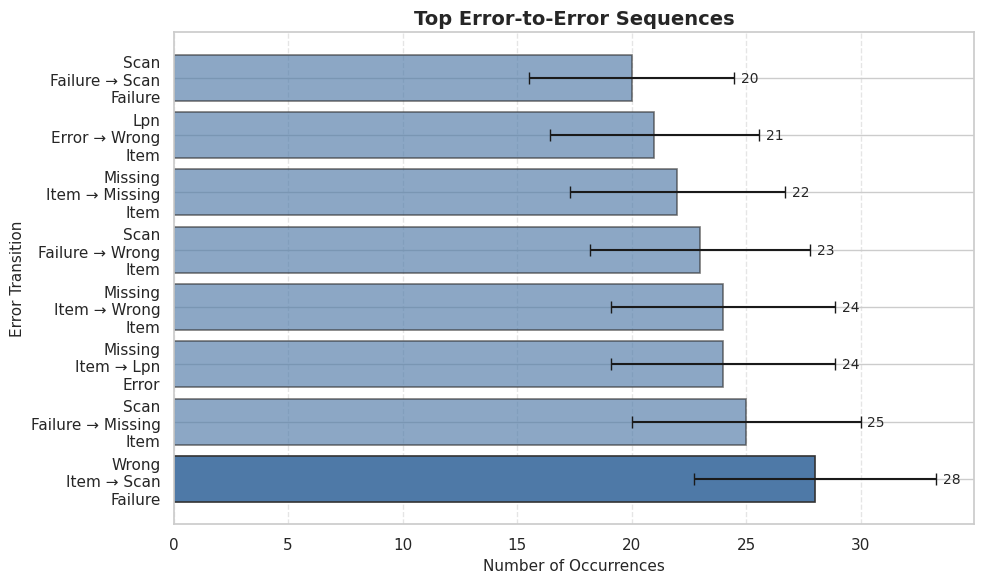

In [30]:
# -----------------------------
# Top recurring error chains
# -----------------------------

chain_data = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .reset_index(name="count")
)

# Remove non-informative transitions
chain_data = chain_data[chain_data["previous_error"] != "no_previous"]

# Sort and keep top chains
chain_data = chain_data.sort_values("count", ascending=False).head(8)

# Format labels for readability
def format_chain_label(prev, curr):
    return (
        "\n".join(prev.replace("_", " ").title().split())
        + " → " +
        "\n".join(curr.replace("_", " ").title().split())
    )

chain_data["chain"] = [
    format_chain_label(p, c)
    for p, c in zip(chain_data["previous_error"], chain_data["error_type"])
]
values = chain_data["count"].values
labels = chain_data["chain"].values

# Approximate variability for visual context
error = np.sqrt(values)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    labels,
    values,
    xerr=error,
    capsize=4,
    color="#4E79A7",
    alpha=0.85,
    edgecolor="#333333",
    linewidth=1.2
)

# Highlight most frequent chain
max_idx = values.argmax()
for i, bar in enumerate(bars):
    if i == max_idx:
        bar.set_alpha(1.0)
    else:
        bar.set_alpha(0.65)

# Display values for quick comparison
for i, v in enumerate(values):
    plt.text(
        v + error[i] + 0.3,
        i,
        f"{v}",
        va="center",
        fontsize=10
    )

plt.title("Top Error-to-Error Sequences", fontsize=14, weight="bold")
plt.xlabel("Number of Occurrences", fontsize=11)
plt.ylabel("Error Transition", fontsize=11)

# Improve readability with vertical reference lines
plt.grid(axis="x", linestyle="--", alpha=0.5)

# Format x-axis
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.tight_layout()
plt.show()

### Key Insight

A small number of error sequences occur repeatedly, indicating that certain failures consistently trigger downstream issues.

These recurring chains suggest that operational problems are not isolated, but follow predictable patterns driven by upstream errors.

In particular, transitions involving item identification and scanning appear frequently, reinforcing their role as key drivers of error propagation.

### Why This Matters

This ranking makes it easier to prioritize interventions by focusing on the most frequent error chains.

By targeting the upstream errors that initiate these sequences, operations can reduce multiple downstream failures at once, improving overall efficiency.

## Error Transition Matrix

### Question  
**How likely is one error to be followed by another?**

After identifying recurring error chains, the next step is to measure how likely each transition is to occur.

This transition matrix converts error-to-error sequences into probabilities, providing a structured view of how failures propagate through the workflow.

It serves as the analytical foundation for the visualizations that follow.

In [37]:
# -----------------------------
# Error transition probability matrix
# -----------------------------
transition_matrix = (
    df.groupby(["previous_error", "error_type"])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to probabilities (row-wise)
transition_matrix = transition_matrix.div(
    transition_matrix.sum(axis=1),
    axis=0
)

transition_matrix

error_type,damage,lpn_error,missing_item,scan_failure,wrong_item
previous_error,,,,,
damage,0.061224,0.122449,0.265306,0.326531,0.224490
lpn_error,0.128571,0.142857,0.257143,0.171429,0.300000
missing_item,0.114583,0.250000,0.229167,0.156250,0.250000
scan_failure,0.133333,0.111111,0.277778,0.222222,0.255556
wrong_item,0.148936,0.202128,0.191489,0.297872,0.159574


### Visualizing Transition Probabilities

To better interpret these relationships, the transition matrix is visualized as a heatmap.

In [39]:
error_impact = {
    "wrong_item": 5,
    "missing_item": 8,
    "lpn_error": 6,
    "scan_failure": 4
}

df["error_cost"] = df["error_type"].map(error_impact)

impact_by_chain = (
    df.groupby(["previous_error", "error_type"])["error_cost"]
    .sum()
    .reset_index()
    .sort_values(by="error_cost", ascending=False)
)

impact_by_chain.head(10)

# “These chains are not just frequent — they are expensive.”

,previous_error,error_type,error_cost
17,scan_failure,missing_item,200.0
12,missing_item,missing_item,176.0
22,wrong_item,missing_item,144.0
11,missing_item,lpn_error,144.0
7,lpn_error,missing_item,144.0
14,missing_item,wrong_item,120.0
19,scan_failure,wrong_item,115.0
21,wrong_item,lpn_error,114.0
23,wrong_item,scan_failure,112.0
9,lpn_error,wrong_item,105.0


In [ ]:
df["risk_score"] = df["error_cost"] + df["previous_error"].map(error_impact).fillna(0)
# rank risky orders
# identify problematic workflows

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Example features
features = ["process_step"]
X = pd.get_dummies(df[features])
y = df["error_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))
# “I can predict operational errors before they happen.”

Accuracy: 0.3


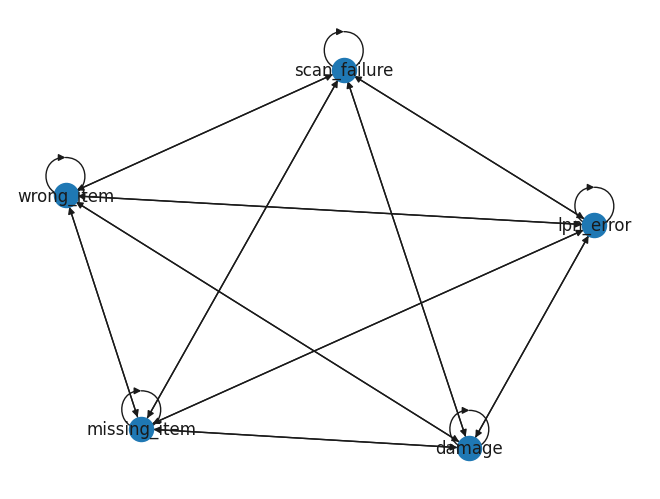

In [36]:
import networkx as nx

G = nx.from_pandas_edgelist(
    chain_counts,
    source="previous_error",
    target="error_type",
    edge_attr="count",
    create_using=nx.DiGraph()
)

nx.draw(G, with_labels=True)

# your system is a failure network


> “I built a system to analyze and model operational error propagation using Python.
I identified high-risk failure chains, quantified their impact, and simulated future error scenarios to support process improvement decisions.”




## Key Insight

The analysis suggests that upstream identification problems,
particularly **barcode scan failures**, frequently trigger
downstream operational issues such as:

- Wrong item selection
- Missing items during packing
- Labeling errors

This indicates that improving **early-stage scanning reliability**
could significantly reduce downstream operational errors.

Potential operational interventions:

• Improve barcode scanning hardware reliability  
• Introduce scan validation checkpoints  
• Provide targeted training for high-error workflow steps  

Reducing upstream scan failures may prevent entire error chains,
improving throughput and operational efficiency.


# Predicting Operational Errors
> “Can we predict which errors are likely to occur based on process conditions?”

In [ ]:
# Example features (adapt to your dataset)
features = ["process_step"]
X = pd.get_dummies(df[features])
y = df["error_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

### Model Findings

## Operational Recommendations

Based on the analysis:

1. Scan failures are a major upstream driver of downstream errors.
   → Recommendation: Improve scanning validation systems.

2. Wrong item errors frequently lead to missing item issues.
   → Recommendation: Introduce verification checkpoints during picking.

3. Certain process steps show higher error concentration.
   → Recommendation: Provide targeted training for those stages

> Add blockquote



# Key Takeaways

Title: Key Takeaways

What goes here:

3 to 5 bullets
summary of what the analysis proved
summary of why it *matters*

# Next Steps

What goes here:

use real warehouse data
improve chain modeling
add cost estimates
test recommendations in production
improve predictive features

Why this matters:
This makes you sound like a consultant and strategist, not just a notebook builder.